**Logistic Regression**

Logistic Regression is used for binary classification. Unlike Linear Regression, which predicts continuous values, Logistic Regression predicts the probability that an input belongs to a specific class (e.g., "Sick" vs. "Healthy").

**Sigmoid Function**: Maps any real-valued number into a range between 0 and 1.

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**The Decision Boundary:** The line that separates our two classes. For 2D data, this is:

$$w_1x_1 + w_2x_2 + b = 0 \implies x_2 = -\left(\frac{w_1}{w_2}\right)x_1 - \left(\frac{b}{w_2}\right)$$



In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

In [10]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=2, 
                           n_redundant=0, n_clusters_per_class=1, random_state=42)

In [11]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [12]:
def logistic_regression_scratch(X, y, lr=0.1, epochs=1000):
    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])
    
    for i in range(epochs):
        j = np.random.randint(0, X.shape[0])
        
        y_hat = sigmoid(np.dot(X[j], weights))
        
        weights = weights + lr * (y[j] - y_hat) * X[j]
        
    return weights[0], weights[1:]

In [18]:
intercept_m, coef_m = logistic_regression_scratch(X, y)
print(intercept_m)
print(coef_m)

2.0727261560729167
[-2.08728167  4.07611461]


In [14]:
lor = LogisticRegression()
lor.fit(X, y)

LogisticRegression()

In [16]:
m_manual = -(coef_m[0] / coef_m[1])
b_manual = -(intercept_m / coef_m[1])

m_sk = -(lor.coef_[0][0] / lor.coef_[0][1])
b_sk = -(lor.intercept_[0] / lor.coef_[0][1])


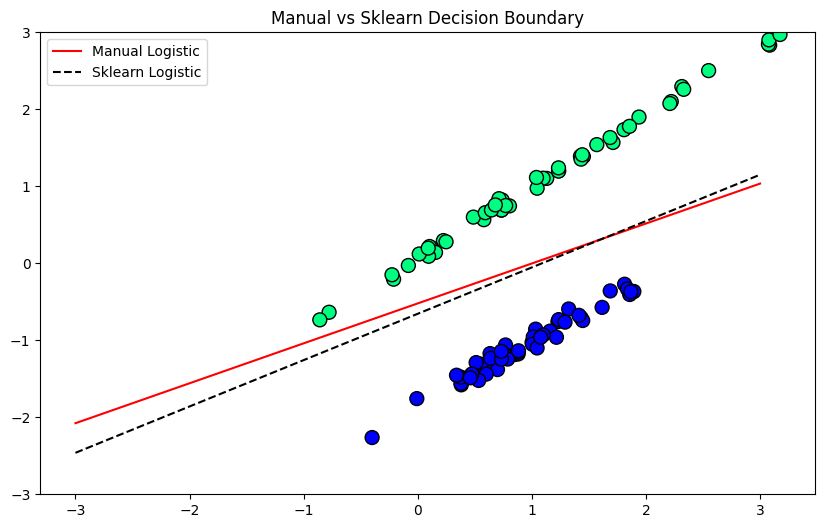

In [17]:
x_input = np.linspace(-3, 3, 100)
y_manual = m_manual * x_input + b_manual
y_sk = m_sk * x_input + b_sk

plt.figure(figsize=(10, 6))
plt.plot(x_input, y_manual, color='red', label='Manual Logistic')
plt.plot(x_input, y_sk, color='black', linestyle='--', label='Sklearn Logistic')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100, edgecolors='k')
plt.ylim(-3, 3)
plt.legend()
plt.title("Manual vs Sklearn Decision Boundary")
plt.show()